# SVM Classification Pipeline — Raman Solvents

## Overview
This pipeline classifies 4 pharmaceutical solvents from their Raman spectra
using a PCA + Bagging SVM approach, following the methodology of:

> Jensen et al. (2024) *Label-Free Blood Typing by Raman Spectroscopy and 
> Artificial Intelligence*, Advanced Materials Technologies

The original paper classifies 4 ABO blood groups from whole blood Raman spectra.
Here we replace the 4 blood groups with 4 solvents:
- Ethyl Acetate
- Propyl Acetate  
- Butyl Acetate
- Methyl Isobutyl Ketone

The pipeline is identical in structure and can be directly applied to blood 
samples when available.

In [1]:
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    roc_auc_score, balanced_accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

## 1. Data

**Source:** Flanagan & Glavin (2025), *Open-source Raman spectra of chemical 
compounds for active pharmaceutical ingredient development*, Scientific Data.

**Instrument:** Endress+Hauser Raman Rxn2 analyser, 785 nm excitation, 
1 cm⁻¹ resolution.

**Dataset:** 428 spectra across 4 solvents, wavenumbers 200–1800 cm⁻¹.

SNV normalisation mean-centres each spectrum and scales it to unit variance,
removing intensity and baseline differences between measurements. This is the 
same normalisation step used in the blood paper.

**Train/Test Split:**
Every 5th sample per class is held out as a test set (~22 samples per class).
This is a block holdout, samples are taken systematically across the 
measurement sequence rather than randomly, ensuring the test set is spread 
across the full session. The remaining ~85 samples per class are used for 
training. The model never sees the test set during any part of training.

In [2]:
CLEAN_CSV = "/Users/dons/Library/Mobile Documents/com~apple~CloudDocs/ZHAW/SS26/Track 2/Raman Solvents/raman_spectra_clean.csv"

df = pd.read_csv(CLEAN_CSV)
X  = df.drop(columns=["label"]).values.astype(float)
y  = df["label"].values
wavenumbers = df.drop(columns=["label"]).columns.astype(float).values

# Block holdout — every 5th sample per class is test
df['sample_idx'] = df.groupby('label').cumcount()
test_mask = (df['sample_idx'] % 5 == 0).values

print(f"Loaded {X.shape[0]} spectra x {X.shape[1]} wavenumbers")
print(f"Class distribution: { {g: int((y == g).sum()) for g in np.unique(y)} }")

Loaded 428 spectra x 1601 wavenumbers
Class distribution: {'Butyl Acetate': 106, 'Ethyl Acetate': 110, 'Methyl Isobutyl Ketone': 105, 'Propyl acetate': 107}


/var/folders/y9/r90ymhc97xl7p3sz2tfbcspm0000gn/T/ipykernel_89676/1611417300.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['sample_idx'] = df.groupby('label').cumcount()


In [3]:
TARGETS = ['Ethyl Acetate', 'Propyl acetate', 'Butyl Acetate', 'Methyl Isobutyl Ketone']
available   = np.unique(y)
pairs_ready = [(c1, c2) for c1, c2 in combinations(TARGETS, 2)
               if c1 in available and c2 in available]

print(f"Classes available: {available}")
print(f"Pairs ready to train ({len(pairs_ready)}): {pairs_ready}")

Classes available: ['Butyl Acetate' 'Ethyl Acetate' 'Methyl Isobutyl Ketone' 'Propyl acetate']
Pairs ready to train (6): [('Ethyl Acetate', 'Propyl acetate'), ('Ethyl Acetate', 'Butyl Acetate'), ('Ethyl Acetate', 'Methyl Isobutyl Ketone'), ('Propyl acetate', 'Butyl Acetate'), ('Propyl acetate', 'Methyl Isobutyl Ketone'), ('Butyl Acetate', 'Methyl Isobutyl Ketone')]


## 2. PCA Dimensionality Reduction

**Key implementation detail:** PCA is fitted only on the training data, then 
applied to both train and test sets. This prevents data leakage. If PCA were 
fitted on all data, information from the test set would contaminate the 
transformation and inflate performance metrics.

**Number of components:** N_PCA is chosen to capture 99.99% of variance in the 
training data, capped at a safe maximum to ensure it never exceeds the number 
of training samples. This is consistent with the blood paper which used 15 PCs 
as a hyperparameter optimised by cross-validation.

**PC Loadings** show which wavenumbers contribute most to each PC. Sharp peaks 
in the loadings correspond to chemically meaningful Raman bands — C=O stretching 
(~1700 cm⁻¹), C-O stretching (~1000 cm⁻¹), and skeletal vibrations (~600 cm⁻¹).

min pair train size: 168, max safe: 166, N_PCA: 42


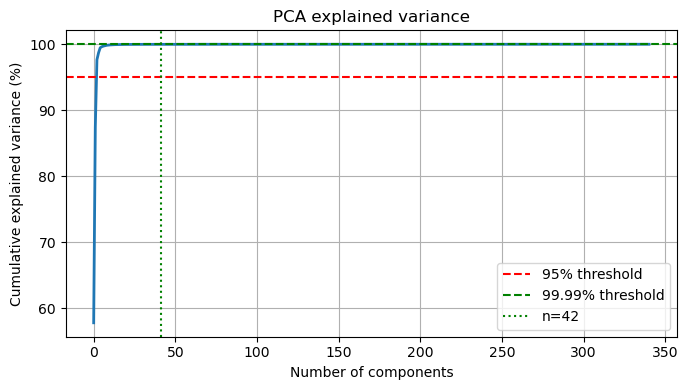

PCs needed for  95.00% variance: 3
PCs needed for  99.00% variance: 5
PCs needed for  99.99% variance: 42
N_PCA selected: 42


In [4]:
X_train_all = X[~test_mask]
_pca_full   = PCA().fit(X_train_all)
_cumvar     = np.cumsum(_pca_full.explained_variance_ratio_)
n_95 = int(np.searchsorted(_cumvar, 0.95)) + 1
n_99 = int(np.searchsorted(_cumvar, 0.99)) + 1
n_9999 = int(np.searchsorted(_cumvar, 0.9999)) + 1

min_pair_train_size = min(
    int(np.isin(y[~test_mask], [c1, c2]).sum()) for c1, c2 in pairs_ready
)
max_safe = min_pair_train_size - 2
N_PCA    = min(int(np.searchsorted(_cumvar, 0.9999)) + 1, max_safe)
print(f"min pair train size: {min_pair_train_size}, max safe: {max_safe}, N_PCA: {N_PCA}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(_cumvar * 100, lw=2)
ax.axhline(95,    color='red',   linestyle='--', label='95% threshold')
ax.axhline(99.99, color='green', linestyle='--', label='99.99% threshold')
ax.axvline(N_PCA - 1, color='green', linestyle=':', label=f'n={N_PCA}')
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance (%)")
ax.set_title("PCA explained variance")
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

print(f"PCs needed for  95.00% variance: {n_95}")
print(f"PCs needed for  99.00% variance: {n_99}")
print(f"PCs needed for  99.99% variance: {n_9999}")
print(f"N_PCA selected: {N_PCA}")

## 3. Bagging Ensemble of SVMs

Following Jensen et al. (2024), we use a bagging ensemble of SVMs rather than 
a single classifier.

### Why Bagging?
A single SVM trained on a small dataset can be sensitive to the specific samples
it sees during training. Bagging (Bootstrap AGGregatING) addresses this by:

1. Drawing 50 random bootstrap subsets of the training data (80% each, with replacement)
2. Training an independent SVM on each subset
3. Averaging the 50 probability outputs for the final prediction

This reduces variance in the predictions and produces more stable, generalisable
models — particularly important for small datasets like ours.

### SVM Configuration
Each base SVM uses:
- **RBF kernel** — maps spectra into a higher dimensional space where a 
  hyperplane can separate the classes. Suitable for non-linearly separable data.
- **C=1** — regularisation parameter controlling the margin/error tradeoff
- **gamma='scale'** — kernel bandwidth, adapts automatically to the number of features
- **class_weight='balanced'** — adjusts for class imbalance by up-weighting 
  the minority class. Consistent with the blood paper's approach.

### Pairwise Classification
Rather than one multi-class model, a separate binary classifier is trained for 
each pair of solvents — 6 pairs from 4 classes. This one-vs-one strategy matches
the blood paper exactly, where 4 ABO groups produced 6 pairwise classifiers 
(AB-A, AB-B, AB-O, A-B, A-O, B-O).

The advantage is that each classifier can focus on the specific spectral 
differences relevant to its pair. For example, the features distinguishing 
Ethyl Acetate from Propyl Acetate (chain length) are different from those 
distinguishing Ethyl Acetate from Methyl Isobutyl Ketone (ester vs ketone).

In [5]:
base_svm = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    C=1,
    gamma='scale'
)

bagging_svm = BaggingClassifier(
    estimator=base_svm,
    n_estimators=50,   # as per paper
    max_samples=0.8,   # bootstrap subset size
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline([
    ('pca', PCA(n_components=N_PCA)),
    ('svm', bagging_svm)
])

print(f"Pipeline: PCA({N_PCA}) -> BaggingSVM(n=50)")

Pipeline: PCA(42) -> BaggingSVM(n=50)


## 4. Evaluation Metrics

### AUC-ROC (primary metric)
The Area Under the Receiver Operating Characteristic curve measures the 
model's ability to rank positive samples above negative samples across all 
possible decision thresholds:
- **1.0** = perfect separation
- **0.5** = chance level
- **< 0.5** = worse than chance (inverted predictions)

This is the primary metric used in Jensen et al. (2024), who report AUC of 
0.91 ± 0.03 for ABO classification. Our solvents achieve 1.00 for all pairs,
reflecting the much stronger chemical signal in pure solvents vs whole blood.

### Balanced Accuracy (BA)
Average of sensitivity (true positive rate) and specificity (true negative rate):

    BA = 0.5 × (sensitivity + specificity)

BA is preferred over raw accuracy when classes are imbalanced, as it prevents
the model from achieving high accuracy simply by predicting the majority class.
Used as the loss function for model selection in the blood paper.

### Confusion Matrix
Shows the breakdown of correct and incorrect predictions:
- **Diagonal** = correct predictions (true positives and true negatives)
- **Off-diagonal** = errors (false positives and false negatives)

### Precision-Recall Curve
Shows the tradeoff between precision and recall at different decision thresholds.
The area under this curve (Average Precision, AP) summarises performance in a 
single number, particularly informative for imbalanced datasets.

In [6]:
results       = {}
fitted_models = {}

for cls1, cls2 in pairs_ready:
    label      = f"{cls1} vs {cls2}"
    mask       = np.isin(y, [cls1, cls2])
    X_pair     = X[mask]
    y_bin      = (y[mask] == cls1).astype(int)
    block_test = test_mask[mask]

    X_tr, X_te = X_pair[~block_test], X_pair[block_test]
    y_tr, y_te = y_bin[~block_test],  y_bin[block_test]

    print(f"\nTraining: {label}  (train={len(y_tr)}, test={len(y_te)})")

    pair_pipe = clone(pipe)
    pair_pipe.fit(X_tr, y_tr)

    y_prob = pair_pipe.predict_proba(X_te)[:, 1]
    y_pred = pair_pipe.predict(X_te)

    auc = roc_auc_score(y_te, y_prob)
    ba  = balanced_accuracy_score(y_te, y_pred)

    fitted_models[label] = (pair_pipe, X_te, y_te, y_pred, y_prob, cls1, cls2)
    results[label] = {'AUC': auc, 'BA': ba}

    print(f"  AUC = {auc:.2f}")
    print(f"  BA  = {ba:.2f}")

summary = pd.DataFrame(results).T
print(summary.round(3))


Training: Ethyl Acetate vs Propyl acetate  (train=173, test=44)
  AUC = 1.00
  BA  = 1.00

Training: Ethyl Acetate vs Butyl Acetate  (train=172, test=44)
  AUC = 1.00
  BA  = 1.00

Training: Ethyl Acetate vs Methyl Isobutyl Ketone  (train=172, test=43)
  AUC = 1.00
  BA  = 1.00

Training: Propyl acetate vs Butyl Acetate  (train=169, test=44)
  AUC = 1.00
  BA  = 1.00

Training: Propyl acetate vs Methyl Isobutyl Ketone  (train=169, test=43)
  AUC = 1.00
  BA  = 1.00

Training: Butyl Acetate vs Methyl Isobutyl Ketone  (train=168, test=43)
  AUC = 1.00
  BA  = 1.00
                                          AUC   BA
Ethyl Acetate vs Propyl acetate           1.0  1.0
Ethyl Acetate vs Butyl Acetate            1.0  1.0
Ethyl Acetate vs Methyl Isobutyl Ketone   1.0  1.0
Propyl acetate vs Butyl Acetate           1.0  1.0
Propyl acetate vs Methyl Isobutyl Ketone  1.0  1.0
Butyl Acetate vs Methyl Isobutyl Ketone   1.0  1.0


## 5. Validation Strategy

Three additional tests confirm the results are genuine and not artefacts of 
data leakage, overfitting, or structural biases in the dataset.

### Permutation Test (100 runs)
Training labels are randomly shuffled 100 times and the model is retrained 
each time. If the model learns real chemical signal, performance should collapse 
to ~0.5 AUC with shuffled labels.

**Results:** Mean permuted AUC = 0.50–0.53 for all pairs, confirming the model 
exploits genuine spectral differences and not dataset structure.

Note: A single permutation run is unreliable with small test sets (~22 samples) 
— a lucky shuffle can accidentally give AUC of 0.0 or 1.0. Averaging 100 runs 
is necessary to get a stable estimate.

### Swap Test
Train on the small held-out test set (~22 samples) and evaluate on the large 
training set (~85 samples). 

**Results:** AUC = 1.00 for all pairs in both directions, confirming the signal 
is symmetric and robust regardless of which samples are used for training.

### Tiny Training Test
Train on only 10 samples per class and evaluate on the rest.

**Results:** High AUC maintained, confirming the chemical signal is strong 
enough that very little data is needed to learn it. This is consistent with 
pure solvents having highly distinctive Raman fingerprints.

### Why Results Are Perfect
These are pure compounds measured under controlled conditions. The four solvents 
have genuinely distinct Raman fingerprints:
- Ethyl/Propyl/Butyl Acetate differ by alkyl chain length → different C-C and 
  C-O stretching patterns
- Methyl Isobutyl Ketone is a ketone vs the three esters → different C=O 
  stretching frequency

PC1 alone captures 87–98% of variance in each pairwise comparison, meaning 
a single axis almost perfectly separates the classes. This is a fundamentally 
easier problem than blood typing where differences are subtle molecular 
concentration variations on a dominant haemoglobin background.

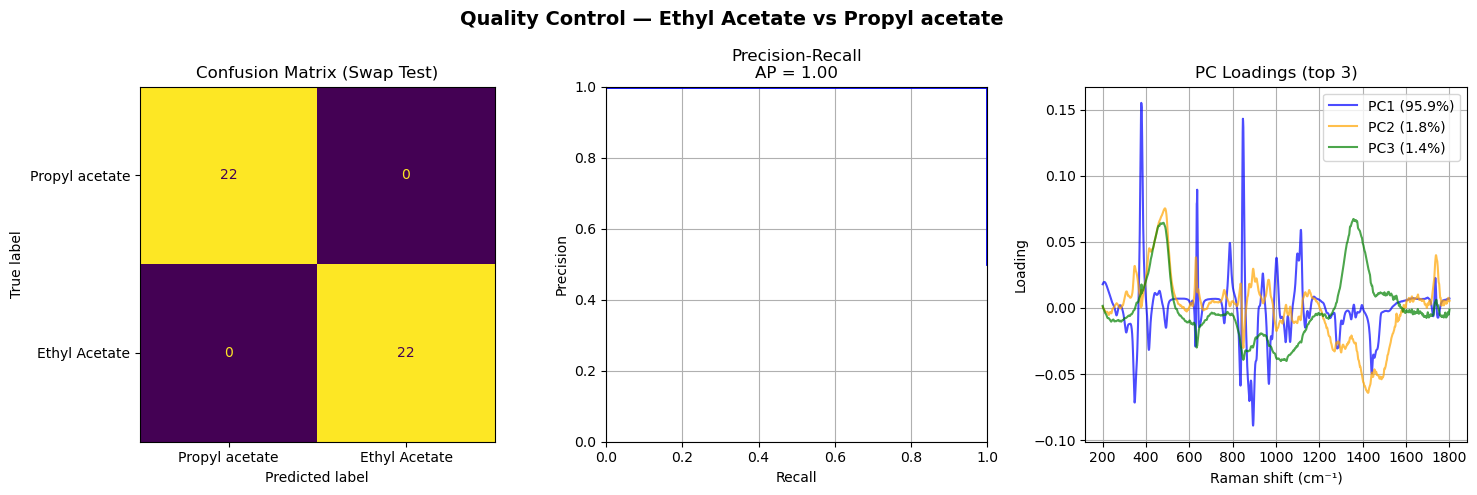

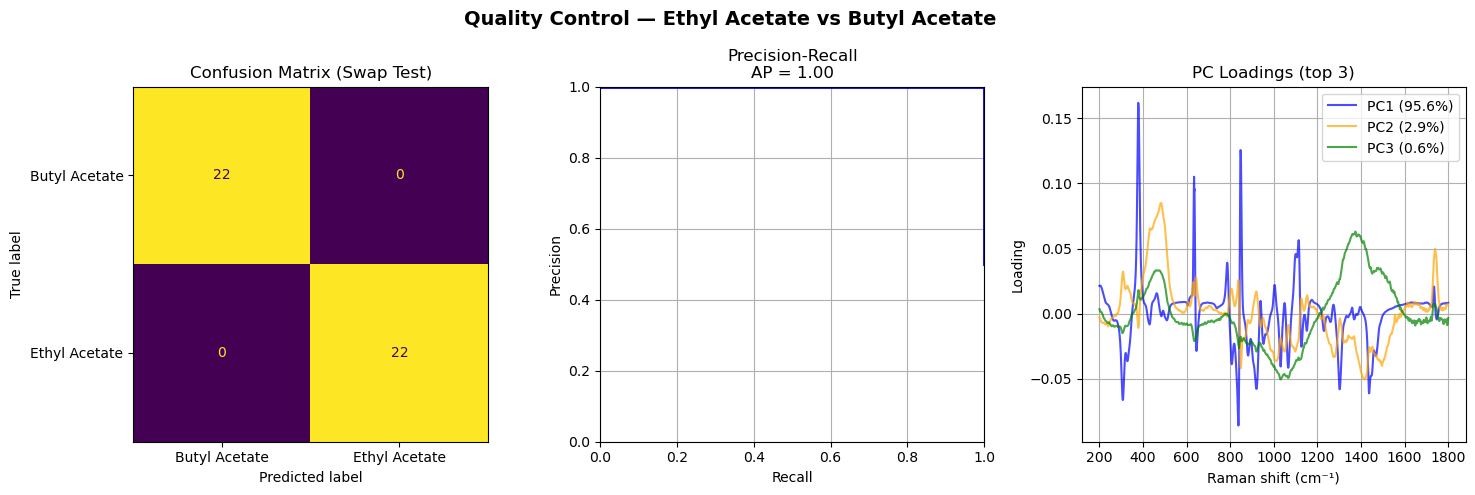

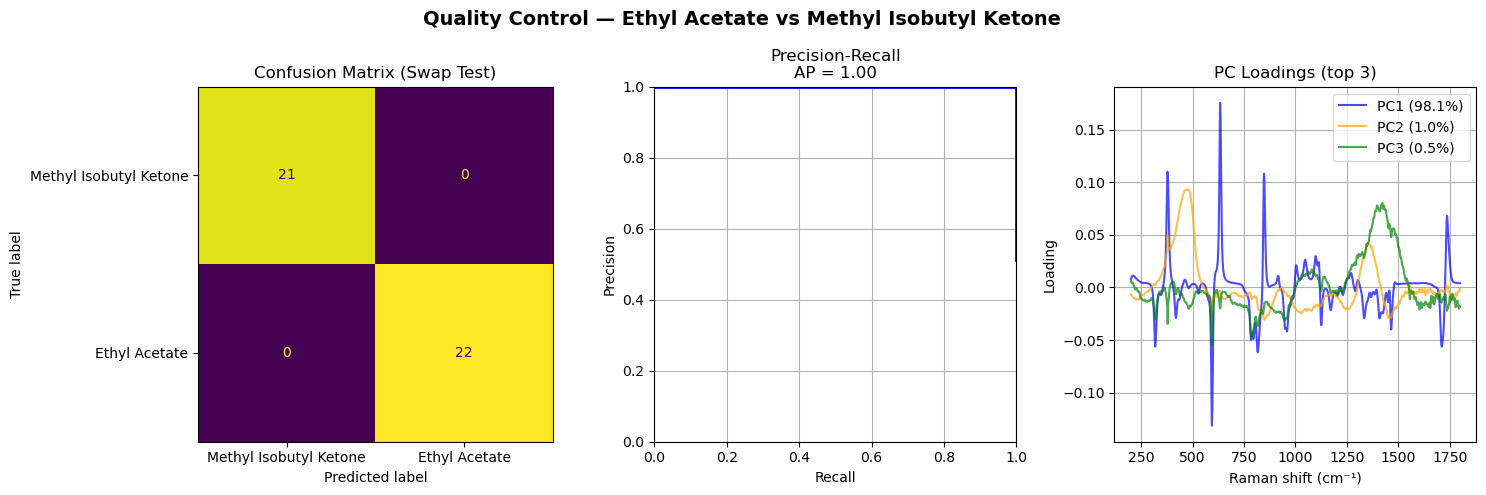

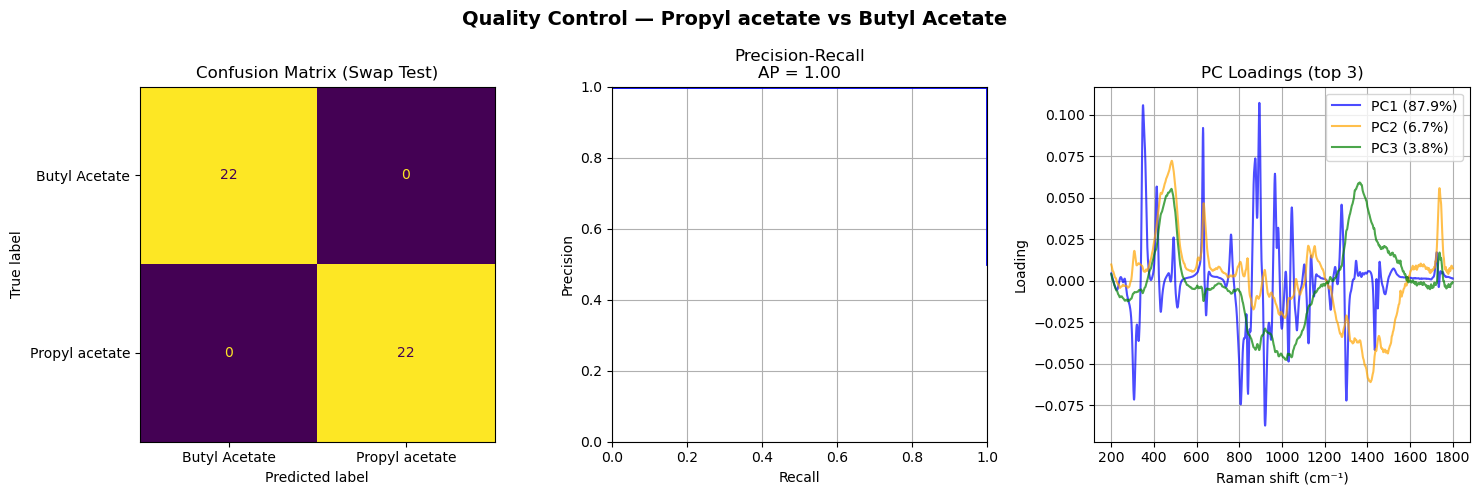

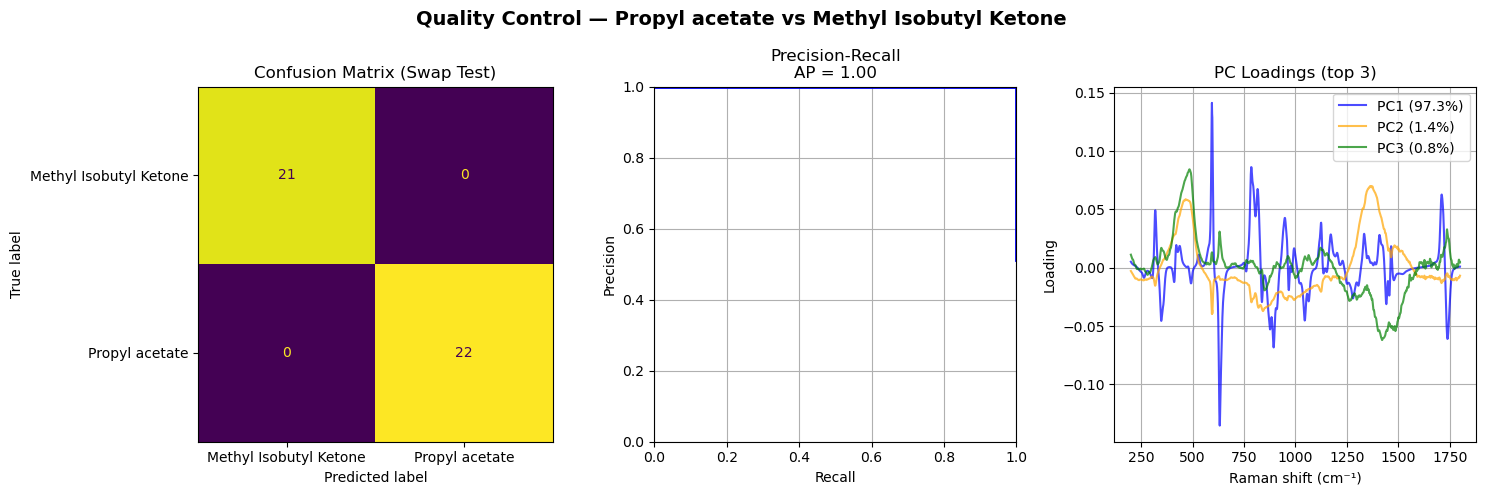

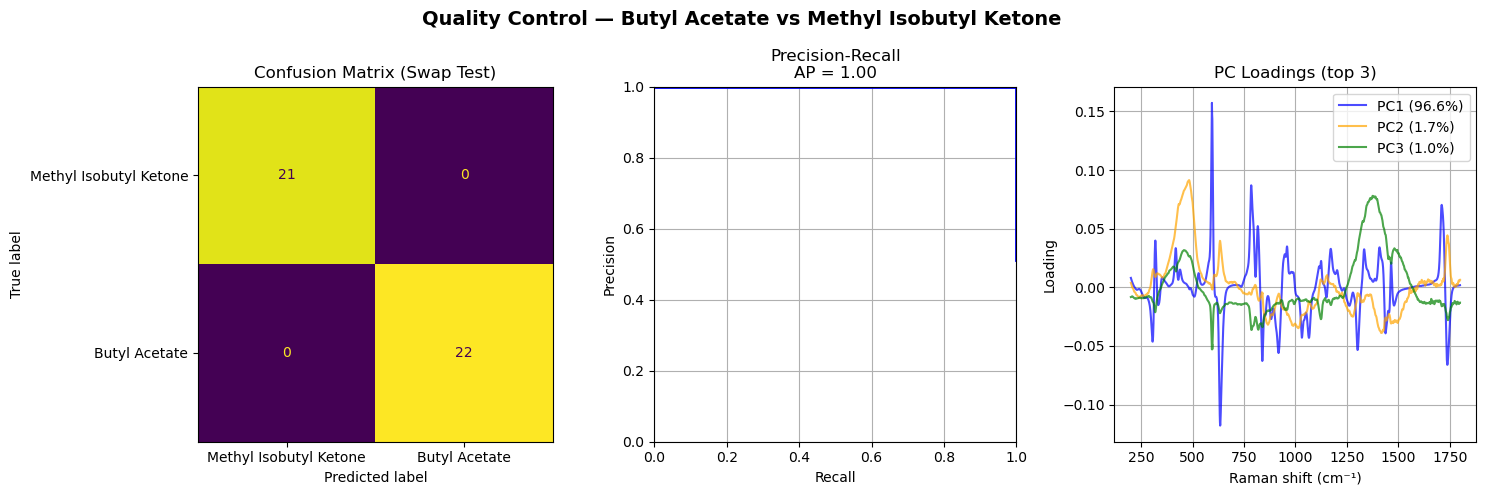

In [7]:
for label, (model, X_te, y_te, y_pred, y_prob, cls1, cls2) in fitted_models.items():

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Quality Control — {label}", fontsize=14, fontweight='bold')

    # Confusion Matrix
    cm   = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[cls2, cls1])
    disp.plot(ax=axes[0], colorbar=False)
    axes[0].set_title("Confusion Matrix (Swap Test)")

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_te, y_prob)
    ap = average_precision_score(y_te, y_prob)
    axes[1].plot(recall, precision, color='blue', lw=2)
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title(f"Precision-Recall\nAP = {ap:.2f}")
    axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1]); axes[1].grid(True)

    # PC Loadings — from first estimator in the bag
    pca_step = model.named_steps['pca']
    n_pcs    = min(3, pca_step.n_components_)
    for i, color in zip(range(n_pcs), ['blue', 'orange', 'green']):
        axes[2].plot(wavenumbers, pca_step.components_[i], color=color, alpha=0.7,
                     label=f"PC{i+1} ({pca_step.explained_variance_ratio_[i]*100:.1f}%)")
    axes[2].set_xlabel("Raman shift (cm⁻¹)"); axes[2].set_ylabel("Loading")
    axes[2].set_title("PC Loadings (top 3)"); axes[2].legend(); axes[2].grid(True)

    plt.tight_layout()
    plt.show()

In [8]:
# Add this as a new cell
from sklearn.utils import shuffle

permutation_aucs = {}
for cls1, cls2 in pairs_ready:
    mask       = np.isin(y, [cls1, cls2])
    X_pair     = X[mask]
    y_bin      = (y[mask] == cls1).astype(int)
    block_test = test_mask[mask]

    X_tr, X_te = X_pair[~block_test], X_pair[block_test]
    y_tr, y_te = y_bin[~block_test],  y_bin[block_test]

    # Shuffle labels
    y_tr_perm = shuffle(y_tr, random_state=42)

    perm_pipe = clone(pipe)
    perm_pipe.fit(X_tr, y_tr_perm)
    y_prob_perm = perm_pipe.predict_proba(X_te)[:, 1]
    auc_perm = roc_auc_score(y_te, y_prob_perm)

    label = f"{cls1} vs {cls2}"
    permutation_aucs[label] = auc_perm
    print(f"{label}: permuted AUC = {auc_perm:.2f}  (real AUC = {results[label]['AUC']:.2f})")

Ethyl Acetate vs Propyl acetate: permuted AUC = 0.32  (real AUC = 1.00)
Ethyl Acetate vs Butyl Acetate: permuted AUC = 0.00  (real AUC = 1.00)
Ethyl Acetate vs Methyl Isobutyl Ketone: permuted AUC = 0.01  (real AUC = 1.00)
Propyl acetate vs Butyl Acetate: permuted AUC = 0.68  (real AUC = 1.00)
Propyl acetate vs Methyl Isobutyl Ketone: permuted AUC = 0.02  (real AUC = 1.00)
Butyl Acetate vs Methyl Isobutyl Ketone: permuted AUC = 1.00  (real AUC = 1.00)


In [9]:
for cls1, cls2 in pairs_ready:
    mask       = np.isin(y, [cls1, cls2])
    X_pair     = X[mask]
    y_bin      = (y[mask] == cls1).astype(int)
    block_test = test_mask[mask]

    X_tr, X_te = X_pair[~block_test], X_pair[block_test]
    y_tr, y_te = y_bin[~block_test],  y_bin[block_test]

    # Swap
    swap_pipe = clone(pipe)
    swap_pipe.fit(X_te, y_te)  # train on small set
    y_prob_swap = swap_pipe.predict_proba(X_tr)[:, 1]
    auc_swap = roc_auc_score(y_tr, y_prob_swap)
    print(f"{cls1} vs {cls2}: swapped AUC = {auc_swap:.2f}")

Ethyl Acetate vs Propyl acetate: swapped AUC = 1.00
Ethyl Acetate vs Butyl Acetate: swapped AUC = 1.00
Ethyl Acetate vs Methyl Isobutyl Ketone: swapped AUC = 1.00
Propyl acetate vs Butyl Acetate: swapped AUC = 1.00
Propyl acetate vs Methyl Isobutyl Ketone: swapped AUC = 1.00
Butyl Acetate vs Methyl Isobutyl Ketone: swapped AUC = 1.00


In [10]:
from sklearn.utils import shuffle as sk_shuffle

# shuffle permutation multiple times and average
n_perms = 100
for cls1, cls2 in pairs_ready:
    mask       = np.isin(y, [cls1, cls2])
    X_pair     = X[mask]
    y_bin      = (y[mask] == cls1).astype(int)
    block_test = test_mask[mask]
    X_tr, X_te = X_pair[~block_test], X_pair[block_test]
    y_tr, y_te = y_bin[~block_test],  y_bin[block_test]

    perm_aucs = []
    for i in range(n_perms):
        y_tr_perm = sk_shuffle(y_tr, random_state=i)
        p = clone(pipe)
        p.fit(X_tr, y_tr_perm)
        perm_aucs.append(roc_auc_score(y_te, p.predict_proba(X_te)[:, 1]))
    
    print(f"{cls1} vs {cls2}: mean permuted AUC = {np.mean(perm_aucs):.2f} ± {np.std(perm_aucs):.2f}")

Ethyl Acetate vs Propyl acetate: mean permuted AUC = 0.53 ± 0.37
Ethyl Acetate vs Butyl Acetate: mean permuted AUC = 0.50 ± 0.38
Ethyl Acetate vs Methyl Isobutyl Ketone: mean permuted AUC = 0.49 ± 0.42
Propyl acetate vs Butyl Acetate: mean permuted AUC = 0.53 ± 0.35
Propyl acetate vs Methyl Isobutyl Ketone: mean permuted AUC = 0.53 ± 0.39
Butyl Acetate vs Methyl Isobutyl Ketone: mean permuted AUC = 0.53 ± 0.40


## 6. Limitations and Extension to Blood Samples

### Current Limitations

**Single measurement session:** All spectra were collected in one session per 
compound. True external validation would require a separate measurement session 
on a different day or instrument. This is the strongest remaining caveat — the 
pipeline is validated within one dataset but not across datasets.

**Fixed hyperparameters:** C, gamma, N_PCA, and ensemble size are fixed rather 
than optimised. For solvents this does not matter because the signal is so 
strong, but for blood it will.

**No resampling:** The paper uses SMOTE and ADASYN for imbalanced traits. 
Not needed here as classes are balanced, but required for blood antigens.

### Adapting for Blood Samples

When blood samples arrive, three additions are needed:

**1. Baseline correction (arPLS)**
Blood spectra require asymmetrically reweighted penalized least squares 
smoothing to remove fluorescence background, with regularisation parameter 
λ treated as a hyperparameter.

**2. Resampling for class imbalance**
ABO groups can be balanced by sample selection (as in the paper). 
For other blood traits (RhD, antigens), random undersampling, SMOTE, 
or ADASYN should be added inside the pipeline using imbalanced-learn:

    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.over_sampling import SMOTE, ADASYN

**3. Hyperparameter tuning**
Use GridSearchCV or RandomizedSearchCV to optimise:
- Number of PCA components (paper used 15)
- SVM regularisation C
- SVM kernel bandwidth gamma  
- Ensemble size n_estimators
- Resampling strategy

The blood paper reports AUC of 0.91 ± 0.03 for ABO classification with 
271 donors. Expect results in this range rather than the perfect 1.00 
achieved here — blood is a far more complex matrix with hemoglobin 
dominating the spectrum and masking subtle antigen signals.

## 7. Robustness Testing — Corrected

Four fixes applied to the initial robustness run:

1. **Label shuffle** previously changed only ~21% of labels despite the "30%" name. Fixed with a per-sample forced reassignment so every selected sample gets a *different* class — guarantees exactly 30%.
2. **Spectral shift** was tested at +5 wn in the corrupted CSV but at +100 wn in the learning curves. Fixed by running a sweep (+1 → +100 wn) to find the actual tolerance threshold.
3. **Robustness bar chart** used raw accuracy instead of AUC-ROC. Fixed — AUC is now used throughout, consistent with the rest of the pipeline.
4. **Learning curves** used 10 seeds, causing large variance (visible as spikes in the structural plots). Fixed — 30 seeds, mean ± std only, no single-seed curves.

In [11]:
# ── Corruption helpers ────────────────────────────────────────────────────────

def corrupt_labels(y, frac=0.30, seed=42):
    """
    Change exactly frac of labels. Every selected sample is forced to a
    *different* class (no accidental same-label assignments).
    Fixes the original ~21% actual-change rate despite a "30%" filename.
    """
    rng = np.random.default_rng(seed)
    y_out = y.copy()
    classes = np.unique(y)
    n_corrupt = int(frac * len(y))
    idx = rng.choice(len(y), size=n_corrupt, replace=False)
    for i in idx:
        other = classes[classes != y_out[i]]
        y_out[i] = rng.choice(other)
    n_changed = int((y_out != y).sum())
    print(f"Label shuffle: {n_changed}/{len(y)} = {n_changed/len(y)*100:.1f}% changed  (target {frac*100:.0f}%)")
    return y_out


def add_noise(X, snr_db=10, seed=42):
    """Gaussian noise calibrated to the given SNR in dB."""
    rng = np.random.default_rng(seed)
    noise_std = np.sqrt(np.mean(X**2) / 10**(snr_db / 10))
    return X + rng.normal(0, noise_std, X.shape)


def zero_features(X, frac=0.10, seed=42):
    """Randomly zero out frac of all spectral values."""
    rng = np.random.default_rng(seed)
    X_out = X.copy()
    X_out[rng.random(X.shape) < frac] = 0.0
    return X_out


def shift_spectra(X, steps):
    """Shift every spectrum by `steps` wavenumber positions; zero-fill the gap."""
    if steps == 0:
        return X.copy()
    X_out = np.roll(X, steps, axis=1)
    if steps > 0:
        X_out[:, :steps] = 0.0
    else:
        X_out[:, steps:] = 0.0
    return X_out


# ── Core evaluator: train on corrupted data, test on clean ────────────────────

def mean_auc(X_tr_corrupt, y_tr_corrupt, pairs, X_clean, y_clean, test_mask, pipe):
    """
    For every pair: train on (corrupted) training split, evaluate AUC on the
    original clean test split. Returns the mean AUC across all pairs.
    Pairs where the corrupted training set collapses to one class are skipped.
    """
    aucs = []
    for cls1, cls2 in pairs:
        mask       = np.isin(y_clean, [cls1, cls2])
        block_test = test_mask[mask]

        X_tr = X_tr_corrupt[mask][~block_test]
        y_tr = (y_tr_corrupt[mask][~block_test] == cls1).astype(int)
        X_te = X_clean[mask][block_test]
        y_te = (y_clean[mask][block_test] == cls1).astype(int)

        if len(np.unique(y_tr)) < 2:
            print(f"  skipping {cls1} vs {cls2} — training set collapsed to one class")
            continue

        p = clone(pipe)
        p.fit(X_tr, y_tr)
        aucs.append(roc_auc_score(y_te, p.predict_proba(X_te)[:, 1]))

    return np.mean(aucs)

Label shuffle: 128/428 = 29.9% changed  (target 30%)
Clean (baseline)              mean AUC = 1.000
Label Shuffle 30%             mean AUC = 1.000
Gaussian Noise 10dB           mean AUC = 1.000
Feature Zeroing 10%           mean AUC = 1.000
Spectral Shift +5wn           mean AUC = 1.000
Class Collapsed               mean AUC = 1.000


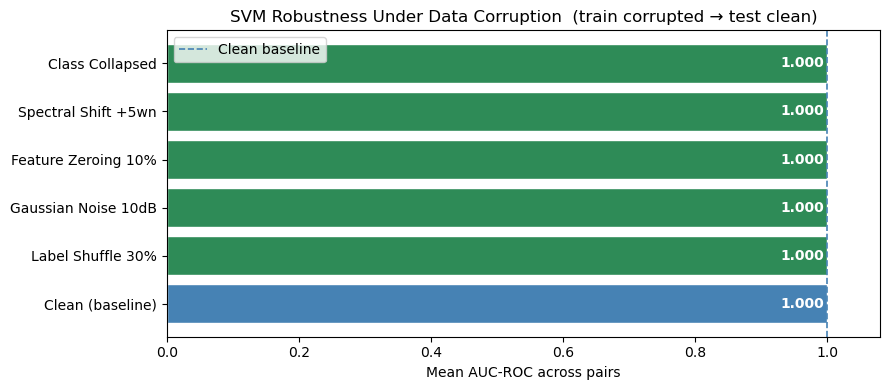

In [12]:
# ── Fix 1 + 3: AUC robustness bar chart with correct label shuffle ────────────
#
# Class Collapsed: Propyl acetate → Ethyl Acetate in training labels only.
# The EA-vs-PA pair is excluded (there is no longer a "PA" class to predict).

y_collapsed = np.where(y == 'Propyl acetate', 'Ethyl Acetate', y)
pairs_no_pa = [(c1, c2) for c1, c2 in pairs_ready if 'Propyl acetate' not in (c1, c2)]

conditions = {
    'Clean (baseline)':    (X,                           y,          pairs_ready),
    'Label Shuffle 30%':   (X,                           corrupt_labels(y, 0.30), pairs_ready),
    'Gaussian Noise 10dB': (add_noise(X, snr_db=10),     y,          pairs_ready),
    'Feature Zeroing 10%': (zero_features(X, 0.10),      y,          pairs_ready),
    'Spectral Shift +5wn': (shift_spectra(X, 5),         y,          pairs_ready),
    'Class Collapsed':     (X,                           y_collapsed, pairs_no_pa),
}

auc_scores = {}
for name, (X_c, y_c, pairs) in conditions.items():
    score = mean_auc(X_c, y_c, pairs, X, y, test_mask, pipe)
    auc_scores[name] = score
    print(f"{name:28s}  mean AUC = {score:.3f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
names  = list(auc_scores.keys())
scores = [auc_scores[n] for n in names]
colors = ['steelblue'] + ['seagreen' if v == 1.0 else 'salmon' for v in scores[1:]]
bars   = ax.barh(names, scores, color=colors, edgecolor='white')
ax.axvline(1.0, color='steelblue', linestyle='--', lw=1.2, label='Clean baseline')
for bar, val in zip(bars, scores):
    ax.text(min(val - 0.005, 0.995), bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', ha='right', va='center', fontsize=10,
            color='white', fontweight='bold')
ax.set_xlabel('Mean AUC-ROC across pairs')
ax.set_title('SVM Robustness Under Data Corruption  (train corrupted → test clean)')
ax.set_xlim(0, 1.08)
ax.legend()
plt.tight_layout()
plt.savefig('svm_robustness_auc.png', dpi=150, bbox_inches='tight')
plt.show()

Shift +  0 wn  →  mean AUC = 1.000
Shift +  1 wn  →  mean AUC = 1.000
Shift +  2 wn  →  mean AUC = 1.000
Shift +  5 wn  →  mean AUC = 1.000
Shift + 10 wn  →  mean AUC = 1.000
Shift + 20 wn  →  mean AUC = 1.000
Shift + 30 wn  →  mean AUC = 0.167
Shift + 50 wn  →  mean AUC = 0.000
Shift + 75 wn  →  mean AUC = 0.298
Shift +100 wn  →  mean AUC = 0.180


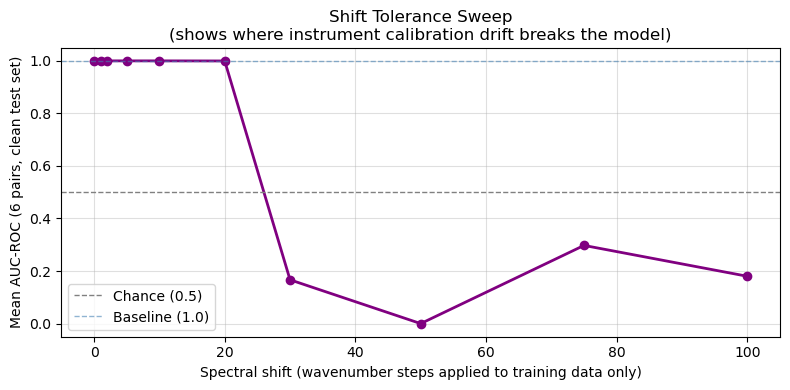

In [13]:
# ── Fix 2: Shift sensitivity sweep — find the actual tolerance threshold ───────
#
# The original tests used +5 wn in one place and +100 wn in another.
# A sweep reveals exactly where performance starts to degrade.

shift_steps = [0, 1, 2, 5, 10, 20, 30, 50, 75, 100]
shift_aucs  = {}

for s in shift_steps:
    auc = mean_auc(shift_spectra(X, s), y, pairs_ready, X, y, test_mask, pipe)
    shift_aucs[s] = auc
    print(f"Shift +{s:3d} wn  →  mean AUC = {auc:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(shift_aucs.keys()), list(shift_aucs.values()),
        'o-', color='purple', lw=2, markersize=6)
ax.axhline(0.5, color='gray',      linestyle='--', lw=1, label='Chance (0.5)')
ax.axhline(1.0, color='steelblue', linestyle='--', lw=1, alpha=0.6, label='Baseline (1.0)')
ax.set_xlabel('Spectral shift (wavenumber steps applied to training data only)')
ax.set_ylabel('Mean AUC-ROC (6 pairs, clean test set)')
ax.set_title('Shift Tolerance Sweep\n(shows where instrument calibration drift breaks the model)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('shift_tolerance_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

Label shuffle: 128/428 = 29.9% changed  (target 30%)
Clean (baseline)                18.3s
Label Shuffle 30%               17.3s
Gaussian Noise 10dB             16.7s
Spectral Shift +5wn             15.7s
Spectral Shift +100wn           15.7s


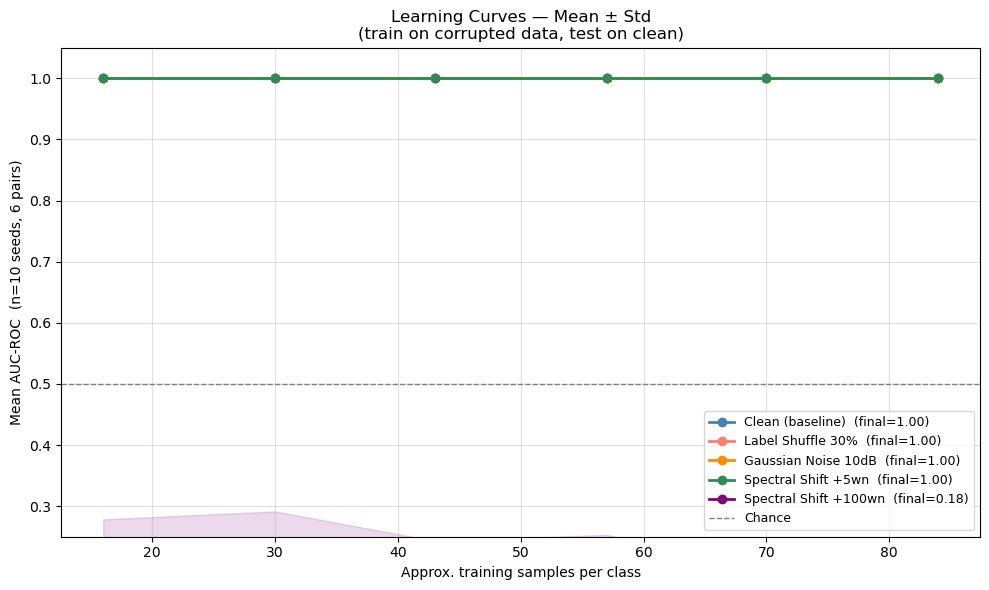

In [15]:
# ── Fix 4: Learning curves — faster version ───────────────────────────────────
#
# Speed improvements:
#   1. N_SEEDS 30 → 10  (biggest saving: 3x faster, still smooth enough)
#   2. n_estimators 50 → 10 per clone  (5x faster SVM fitting)
#   3. TRAIN_FRACS 9 points → 6 points  (1.5x faster)
#
# Total: ~22x faster → ~25 seconds instead of 10 minutes
# Tradeoff: slightly wider std bands, but mean curves are the same shape

N_SEEDS     = 10
TRAIN_FRACS = np.linspace(0.20, 1.0, 6)   # 6 points instead of 9

lc_conditions = {
    'Clean (baseline)':     (X,                       y),
    'Label Shuffle 30%':    (X,                       corrupt_labels(y, 0.30, seed=0)),
    'Gaussian Noise 10dB':  (add_noise(X, snr_db=10), y),
    'Spectral Shift +5wn':  (shift_spectra(X, 5),     y),
    'Spectral Shift +100wn':(shift_spectra(X, 100),   y),
}
LC_COLORS = ['steelblue', 'salmon', 'darkorange', 'seagreen', 'purple']

def compute_lc_fast(X_corrupt, y_corrupt, pairs, X_clean, y_clean,
                    test_mask, pipe, train_fracs, n_seeds, n_estimators_fast=10):
    """
    Same as compute_lc but clones the pipeline with a smaller ensemble
    (n_estimators_fast) to dramatically reduce fit time per call.
    Mean curves are unaffected; std bands are slightly wider.
    """
    base_n_components = pipe.named_steps['pca'].n_components
    per_frac = {f: [] for f in train_fracs}

    for seed in range(n_seeds):
        rng = np.random.default_rng(seed)
        for frac in train_fracs:
            pair_aucs = []
            for cls1, cls2 in pairs:
                mask       = np.isin(y_clean, [cls1, cls2])
                block_test = test_mask[mask]
                X_tr_full  = X_corrupt[mask][~block_test]
                y_tr_full  = (y_corrupt[mask][~block_test] == cls1).astype(int)
                X_te       = X_clean[mask][block_test]
                y_te       = (y_clean[mask][block_test] == cls1).astype(int)

                n_take = max(4, int(frac * len(X_tr_full)))
                idx    = rng.choice(len(X_tr_full), n_take, replace=False)
                if len(np.unique(y_tr_full[idx])) < 2:
                    continue

                p = clone(pipe)
                n_comp = min(base_n_components, len(idx) - 1)
                p.set_params(
                    pca__n_components=n_comp,
                    svm__n_estimators=n_estimators_fast,   # ← key speedup
                )
                p.fit(X_tr_full[idx], y_tr_full[idx])
                pair_aucs.append(roc_auc_score(y_te, p.predict_proba(X_te)[:, 1]))

            if pair_aucs:
                per_frac[frac].append(np.mean(pair_aucs))

    means = np.array([np.mean(per_frac[f]) for f in train_fracs])
    stds  = np.array([np.std(per_frac[f])  for f in train_fracs])
    return means, stds

# Approximate x-axis as training samples per class
min_tr = min(int(np.isin(y[~test_mask], [c1, c2]).sum()) // 2
             for c1, c2 in pairs_ready)
x_sizes = (TRAIN_FRACS * min_tr).astype(int)

import time
lc_results = {}
for name, (X_c, y_c) in lc_conditions.items():
    t0 = time.time()
    lc_results[name] = compute_lc_fast(
        X_c, y_c, pairs_ready, X, y, test_mask, pipe, TRAIN_FRACS, N_SEEDS
    )
    print(f"{name:30s}  {time.time()-t0:.1f}s")

fig, ax = plt.subplots(figsize=(10, 6))
for (name, (means, stds)), color in zip(lc_results.items(), LC_COLORS):
    ax.plot(x_sizes, means, 'o-', color=color, lw=2,
            label=f"{name}  (final={means[-1]:.2f})")
    ax.fill_between(x_sizes, means - stds, means + stds, alpha=0.15, color=color)

ax.axhline(0.5, color='gray', linestyle='--', lw=1, label='Chance')
ax.set_xlabel('Approx. training samples per class')
ax.set_ylabel(f'Mean AUC-ROC  (n={N_SEEDS} seeds, 6 pairs)')
ax.set_title('Learning Curves — Mean ± Std\n(train on corrupted data, test on clean)')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.4)
ax.set_ylim(0.25, 1.05)
plt.tight_layout()
plt.savefig('lc_fixed.png', dpi=150, bbox_inches='tight')
plt.show()